<a href="https://colab.research.google.com/github/sahasraa178/Machine-Learning-sem-4/blob/main/ML_lab_assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**MACHINE LEARNING LAB ASSIGNMENT 5**

BL.SC.U4AIE24009


B.SAHASRAA

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving BERT_Embeddings.xlsx to BERT_Embeddings (2).xlsx


In [ ]:
df = pd.read_excel("BERT_Embeddings.xlsx", header=0)
print(df.columns.tolist())


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

**A1**

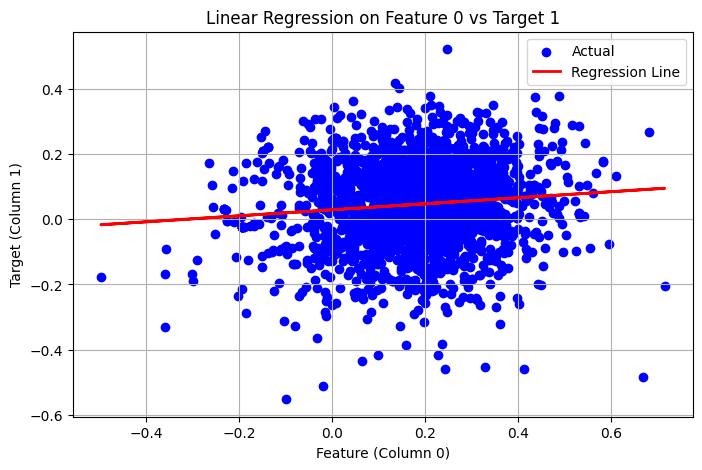

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Used column 0 as feature and column 1 as target
X = df[[0]].values   # Feature column (must be 2D)
y = df[1].values     # Target column (must be 1D)

# Spliting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Training linear regression model
reg = LinearRegression().fit(X_train, y_train)
y_train_pred = reg.predict(X_train)

# Ploting regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Actual')
plt.plot(X_train, y_train_pred, color='red', linewidth=2, label='Regression Line')
plt.title("Linear Regression on Feature 0 vs Target 1")
plt.xlabel("Feature (Column 0)")
plt.ylabel("Target (Column 1)")
plt.legend()
plt.grid(True)
plt.show()


**A2**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

def evaluate_model_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Set Metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Test Set Metrics
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return mse_train, rmse_train, mape_train, r2_train, mse_test, rmse_test, mape_test, r2_test

# Calling the function with the trained model and data
mse_train, rmse_train, mape_train, r2_train, mse_test, rmse_test, mape_test, r2_test = evaluate_model_metrics(
    reg, X_train, y_train, X_test, y_test
)

print("🔹 Training Set Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAPE: {mape_train:.4f}")
print(f"R²: {r2_train:.4f}")

print("\n🔹 Test Set Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAPE: {mape_test:.4f}")
print(f"R²: {r2_test:.4f}")

🔹 Training Set Metrics:
MSE: 0.0158
RMSE: 0.1256
MAPE: 1.9869
R²: 0.0106

🔹 Test Set Metrics:
MSE: 0.0164
RMSE: 0.1281
MAPE: 1.8946
R²: -0.0016


**A3**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

def prepare_data_all_features(df, target_col_name):
    # Identifying all numeric columns (0 to 767) as features
    numeric_cols = [col for col in df.columns if isinstance(col, int) and 0 <= col <= 767]

    # Features are all numeric columns except the target
    feature_cols = [col for col in numeric_cols if col != target_col_name]
    X = df[feature_cols].values

    # Target variable
    y = df[target_col_name].values

    # Spliting data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    return X_train, X_test, y_train, y_test

def train_linear_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Set Metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Test Set Metrics
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return mse_train, rmse_train, mape_train, r2_train, mse_test, rmse_test, mape_test, r2_test

# Main Program

# Defining the target column
target_col_index = 1

# Preparing data using all other numeric features
X_train, X_test, y_train, y_test = prepare_data_all_features(df, target_col_index)

# Training the model
model = train_linear_model(X_train, y_train)

# Evaluating model performance
mse_train, rmse_train, mape_train, r2_train, mse_test, rmse_test, mape_test, r2_test = evaluate_model_metrics(
    model, X_train, y_train, X_test, y_test
)

# Printing training metrics
print("🔹 Training Set Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAPE: {mape_train:.4f}")
print(f"R²: {r2_train:.4f}")

# Printing test metrics
print("\n🔹 Test Set Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAPE: {mape_test:.4f}")
print(f"R²: {r2_test:.4f}")

🔹 Training Set Metrics:
MSE: 0.0000
RMSE: 0.0000
MAPE: 0.0001
R²: 1.0000

🔹 Test Set Metrics:
MSE: 0.0000
RMSE: 0.0000
MAPE: 0.0001
R²: 1.0000


In [ ]:
import pandas as pd


# df, target_col_index, X_train, X_test, y_train, y_test

print("Shape of original DataFrame:", df.shape)
print("Target column index:", target_col_index)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of original DataFrame: (3311, 771)
Target column index: 1
Shape of X_train: (2317, 767)
Shape of X_test: (994, 767)
Shape of y_train: (2317,)
Shape of y_test: (994,)


**A4**

In [ ]:
from sklearn.cluster import KMeans

def prepare_clustering_data(df, target_col_index):
    # Identifing all numerical columns (0 to 767) for clustering
    numeric_cols = [col for col in df.columns if isinstance(col, int) and 0 <= col <= 767]

    # Excluding the target column from the features for clustering
    features_for_clustering = [col for col in numeric_cols if col != target_col_index]

    return df[features_for_clustering].values

def perform_kmeans_clustering(X, n_clusters=2, random_state=0):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    kmeans.fit(X)
    return kmeans.labels_, kmeans.cluster_centers_

# Main Program

# Replacing with actual target column index (e.g., 1)
target_col_index = 1

# Preparing data for clustering (excluding the target column and other non-numeric columns)
X_cluster = prepare_clustering_data(df, target_col_index)

# Performing K-Means clustering
labels, centers = perform_kmeans_clustering(X_cluster, n_clusters=2, random_state=0)

# Printing results
print("Cluster Labels (first 10):", labels[:10])
print("Cluster Centers Shape:", centers.shape)

Cluster Labels (first 10): [1 1 1 0 1 1 0 0 0 0]
Cluster Centers Shape: (2, 767)


**A5**

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans

def evaluate_clustering_metrics(X, labels):
    silhouette = silhouette_score(X, labels)
    ch_score = calinski_harabasz_score(X, labels)
    db_index = davies_bouldin_score(X, labels)
    return silhouette, ch_score, db_index

# Main Program

# X_cluster and labels are available from cell PyL44PRsc74Y, which performed the clustering.
# Therefore, we directly used these for evaluation.

silhouette_score_val, ch_score_val, db_index_val = evaluate_clustering_metrics(X_cluster, labels)

# Print results
print("🔹 Clustering Evaluation Metrics:")
print(f"Silhouette Score: {silhouette_score_val:.4f}")
print(f"Calinski-Harabasz Score: {ch_score_val:.4f}")
print(f"Davies-Bouldin Index: {db_index_val:.4f}")


🔹 Clustering Evaluation Metrics:
Silhouette Score: 0.1123
Calinski-Harabasz Score: 488.8256
Davies-Bouldin Index: 2.4481


**A6**

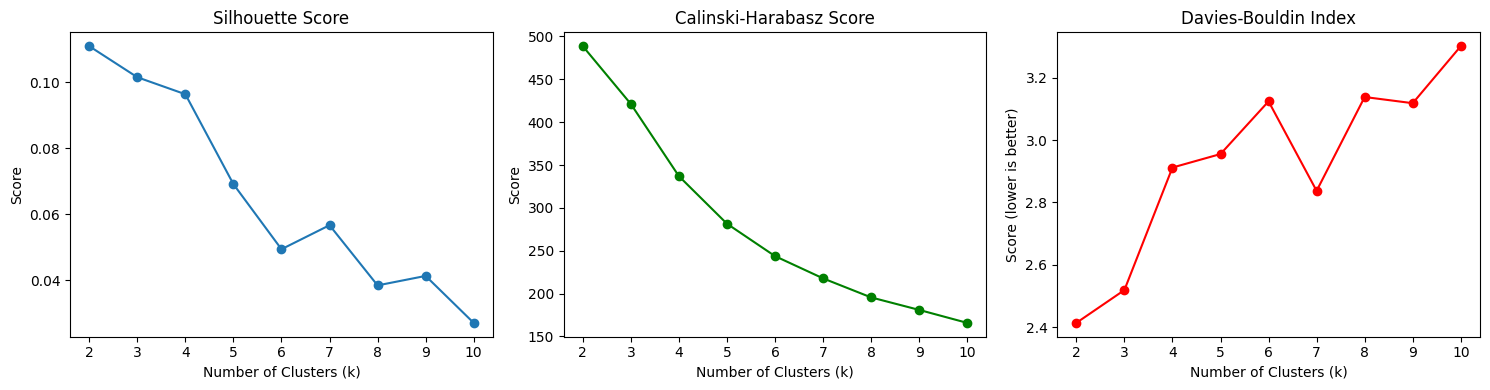

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

def evaluate_kmeans_for_k_range(X, k_values, random_state=42):
    silhouette_scores = []
    ch_scores = []
    db_scores = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = kmeans.fit_predict(X)

        silhouette = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)

        silhouette_scores.append(silhouette)
        ch_scores.append(ch)
        db_scores.append(db)

    return silhouette_scores, ch_scores, db_scores

def plot_clustering_metrics(k_values, silhouette_scores, ch_scores, db_scores):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(k_values, silhouette_scores, marker='o')
    plt.title("Silhouette Score")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")

    plt.subplot(1, 3, 2)
    plt.plot(k_values, ch_scores, marker='o', color='green')
    plt.title("Calinski-Harabasz Score")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")

    plt.subplot(1, 3, 3)
    plt.plot(k_values, db_scores, marker='o', color='red')
    plt.title("Davies-Bouldin Index")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score (lower is better)")

    plt.tight_layout()
    plt.show()

# Main Program

def prepare_clustering_data(df, target_col_index):
    numeric_cols = [col for col in df.columns if isinstance(col, int) and 0 <= col <= 767]
    features_for_clustering = [col for col in numeric_cols if col != target_col_index]
    return df[features_for_clustering].values

target_col_index = 1
X_cluster = prepare_clustering_data(df, target_col_index)

# Defining range of k values to test
k_values = list(range(2, 11)) # Testing k from 2 to 10

# Evaluating clustering metrics for each k
silhouette_scores, ch_scores, db_scores = evaluate_kmeans_for_k_range(X_cluster, k_values)

# Ploting the metrics
plot_clustering_metrics(k_values, silhouette_scores, ch_scores, db_scores)

**A7**

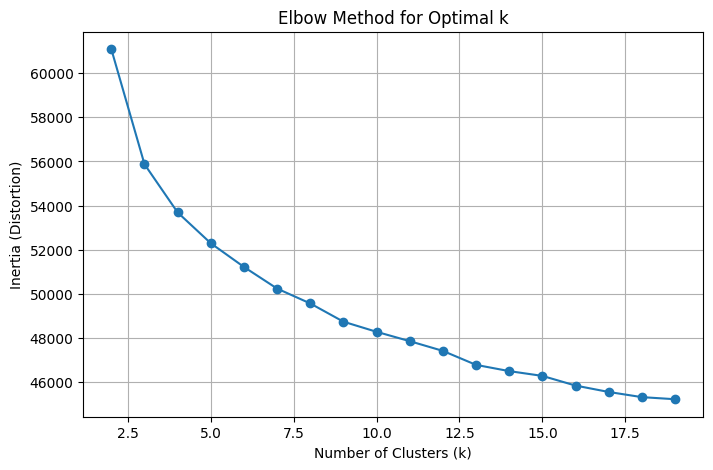

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def compute_elbow_distortions(X, k_range, random_state=42):
    distortions = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        kmeans.fit(X)
        distortions.append(kmeans.inertia_)
    return distortions

def plot_elbow_curve(k_range, distortions):
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, distortions, marker='o')
    plt.title("Elbow Method for Optimal k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (Distortion)")
    plt.grid(True)
    plt.show()

# Main Program

# Preparing data
def prepare_clustering_data(df, target_col_index):
    numeric_cols = [col for col in df.columns if isinstance(col, int) and 0 <= col <= 767]
    features_for_clustering = [col for col in numeric_cols if col != target_col_index]
    return df[features_for_clustering].values

target_col_index = 1
X_cluster = prepare_clustering_data(df, target_col_index)

# Defining k range
k_range = range(2, 20) # Test k from 2 to 19

# Computing distortions
distortions = compute_elbow_distortions(X_cluster, k_range)

# Ploting elbow curve
plot_elbow_curve(k_range, distortions)
